# Building Makemore: Building a WaveNet

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('assets/names.txt').read().splitlines()

# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print("vocab_size -> ", vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
vocab_size ->  27


In [3]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## Base cpde from part 4: activations, gradients, and batchnorm (pytorch-fied code)

In [4]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / (fan_in**0.5)
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] if self.bias is None else [self.weight, self.bias]

# ---------------------------------------------------------------------------------
class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.Training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass
        if self.Training:
            xmean = x.mean(0, keepdim=True) # mean over batch
            xvar = x.var(0, keepdim=True) # variance over batch
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        if self.Training:
            # update running mean and variance
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

In [5]:
torch.manual_seed(42) # move generator outside, seed for reproducibility

In [6]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
C = torch.randn(vocab_size, n_embd)
layers = [
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
]

with torch.no_grad():
    layers[-1].weight *= 0.1 # last layer is scaled down to 0.1 to prevent saturation

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True


12097


In [7]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        embcat = layer(embcat)
    loss = F.cross_entropy(embcat, Yb) # loss function
    
    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])

      0/ 200000: 3.2966
  10000/ 200000: 2.2322
  20000/ 200000: 2.4111
  30000/ 200000: 2.1004
  40000/ 200000: 2.3157
  50000/ 200000: 2.2104
  60000/ 200000: 1.9653
  70000/ 200000: 1.9767
  80000/ 200000: 2.6738
  90000/ 200000: 2.0837
 100000/ 200000: 2.2730
 110000/ 200000: 1.7087
 120000/ 200000: 2.3243
 130000/ 200000: 2.2512
 140000/ 200000: 2.0113
 150000/ 200000: 1.8195
 160000/ 200000: 1.7985
 170000/ 200000: 2.2206
 180000/ 200000: 2.0566
 190000/ 200000: 2.1030


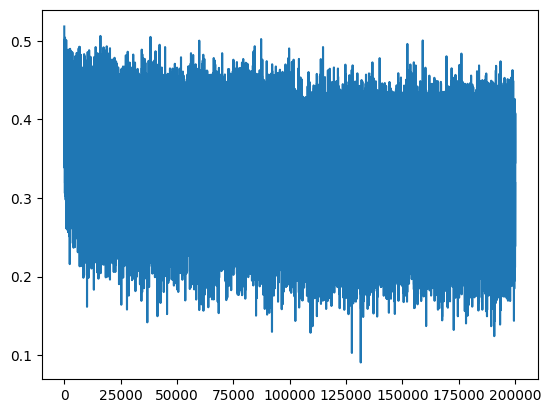

In [8]:
plt.plot(lossi)

In [9]:
for layer in layers:
    layer.Training = False # switch to inference mode

In [10]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0621414184570312
val 2.109346389770508


In [11]:
# sample from the model

for _ in range(20):
    out = []
    context = [0] * block_size # start with a context of zeros
    while True:
        # forward pass the neural network
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        embcat = emb.view(emb.shape[0], -1) # concatenate the embeddings
        for layer in layers:
            embcat = layer(embcat)
        logits = embcat # (1, vocab_size)
        probs = F.softmax(logits, dim=1) # convert to probabilities
        ix = torch.multinomial(probs, num_samples=1).item() # sample from the distribution
        context = context[1:] + [ix] # update context
        out.append(ix) # convert index to character
        if ix == 0: break # stop if we hit the end token
    
    print(''.join(itos[i] for i in out))

ivon.
fanili.
thoommasamiel.
emmadery.
andr.
aleigh.
kelynnie.
jazul.
carleen.
jah.
jorra.
alaya.
shonan.
vishylaharia.
juna.
vio.
orven.
meriell.
laiye.
zefina.


## Improvements on above code - pytorchfying it

### Lets fix learning rate graph

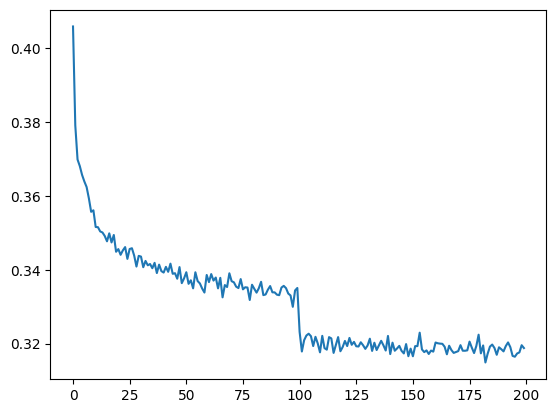

In [12]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

### simplifying layers

In [13]:
class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, x):
        self.out = self.weight[x]
        return self.out

    def parameters(self):
        return [self.weight]

class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out

    def parameters(self):
        return []

In [14]:
n_embd = 10
n_hidden = 200

# now that we have the embedding layer, we can use it to create the layers and
# simplify the code
layers = [
    Embedding(vocab_size, n_embd),
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
]

with torch.no_grad():
    layers[-1].weight *= 0.1

parameters = [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12097


In [15]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    # now our forward pass is much simpler as
    # we can just pass the input through the layers
    embcat = Xb
    for layer in layers:
        embcat = layer(embcat)
    loss = F.cross_entropy(embcat, Yb) # loss function
    
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.2763
  10000/ 200000: 2.1892
  20000/ 200000: 2.4163
  30000/ 200000: 2.3883
  40000/ 200000: 2.3692
  50000/ 200000: 2.1804
  60000/ 200000: 2.1237
  70000/ 200000: 1.7958
  80000/ 200000: 2.1753
  90000/ 200000: 2.1354
 100000/ 200000: 1.7864
 110000/ 200000: 2.0931
 120000/ 200000: 1.6485
 130000/ 200000: 1.7828
 140000/ 200000: 1.7228
 150000/ 200000: 2.1221
 160000/ 200000: 2.4011
 170000/ 200000: 2.5772
 180000/ 200000: 2.2987
 190000/ 200000: 2.3366


### pytorch containers

right now we are storing our modules in naked list of layers. We can use pytorch containers

In [16]:
class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [17]:
n_embd = 10
n_hidden = 200

# using pytorch like containers to create the model
model = Sequential([
    Embedding(vocab_size, n_embd),
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12097


In [18]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    # now our forward pass is much simpler as
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb) # loss function
    
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3106
  10000/ 200000: 2.1975
  20000/ 200000: 2.5387
  30000/ 200000: 2.0430
  40000/ 200000: 2.5641
  50000/ 200000: 2.1973
  60000/ 200000: 2.3103
  70000/ 200000: 2.0752
  80000/ 200000: 2.6588
  90000/ 200000: 2.1813
 100000/ 200000: 1.8195
 110000/ 200000: 1.9398
 120000/ 200000: 2.0316
 130000/ 200000: 2.2127
 140000/ 200000: 2.4063
 150000/ 200000: 2.0677
 160000/ 200000: 1.9487
 170000/ 200000: 2.1902
 180000/ 200000: 1.9938
 190000/ 200000: 1.9277


In [19]:
for layer in model.layers:
    layer.Training = False # switch to inference mode

In [20]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0665063858032227
val 2.1086182594299316


In [21]:
# sample from the model

for _ in range(20):
    out = []
    context = [0] * block_size # start with a context of zeros
    while True:
        # forward pass the neural network
        logits = model(torch.tensor([context])) # (1, vocab_size)
        probs = F.softmax(logits, dim=1) # convert to probabilities
        ix = torch.multinomial(probs, num_samples=1).item() # sample from the distribution
        context = context[1:] + [ix] # update context
        out.append(ix) # convert index to character
        if ix == 0: break # stop if we hit the end token
    
    print(''.join(itos[i] for i in out))

termarin.
verlia.
azlynn.
jina.
kyelie.
ell.
maxrialys.
emmy.
seal.
sandroy.
izs.
prisse.
awdai.
rayna.
ana.
noor.
kenleah.
thebel.
anlee.
avely.


## Implementing Wavenet

### increae context length (block size) to 8

In [22]:
# increase block size to 8
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [23]:
for x, y in zip(Xtr[:10], Ytr[:10]):
    print(''.join(itos[i.item()] for i in x), '----->', itos[y.item()])

........ -----> y
.......y -----> u
......yu -----> h
.....yuh -----> e
....yuhe -----> n
...yuhen -----> g
..yuheng -----> .
........ -----> d
.......d -----> i
......di -----> o


In [24]:
n_embd = 10
n_hidden = 200

# using pytorch like containers to create the model
model = Sequential([
    Embedding(vocab_size, n_embd),
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

22097


In [25]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    # now our forward pass is much simpler as
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb) # loss function
    
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.2847
  10000/ 200000: 2.3979
  20000/ 200000: 1.8162
  30000/ 200000: 2.4864
  40000/ 200000: 2.0995
  50000/ 200000: 2.0681
  60000/ 200000: 1.8912
  70000/ 200000: 2.2705
  80000/ 200000: 2.0631
  90000/ 200000: 2.0846
 100000/ 200000: 1.9280
 110000/ 200000: 2.0633
 120000/ 200000: 1.8321
 130000/ 200000: 1.7780
 140000/ 200000: 2.0450
 150000/ 200000: 2.4472
 160000/ 200000: 1.9487
 170000/ 200000: 1.7305
 180000/ 200000: 2.3656
 190000/ 200000: 1.8173


In [26]:
for layer in model.layers:
    layer.Training = False # switch to inference mode

In [27]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.929003119468689
val 2.0298044681549072


**performance log**
* original (3 character context + 200 hidden neurons, 12k params): train 2.066, val 2.108
* new context 3 -> 8 (22k params): train 1.927, val 2.027

*quite a bit of improvement by increasing context length*

### scratch pad to understand forward pass

In [28]:
ix = torch.randint(0, Xtr.shape[0], (4,)) # lets look at 4 random examples
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0, 10, 21, 12,  9],
        [ 0,  0,  0,  0,  0,  0, 10,  5],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0, 19,  8, 18,  9]])

In [29]:
model.layers[0].out.shape

torch.Size([4, 8, 10])

In [30]:
model.layers[1].out.shape

torch.Size([4, 80])

In [31]:
model.layers[2].out.shape

torch.Size([4, 200])

In [32]:
(torch.randn(4, 80) @ torch.randn(80, 200) + torch.randn(200)).shape

torch.Size([4, 200])

In [33]:
(torch.randn(4, 8, 80) @ torch.randn(80, 200) + torch.randn(200)).shape

torch.Size([4, 8, 200])

test test